Percentages representing win/draw/loss from the perspective of the FirstAgent against the SecondAgent, example:

```DQN vs PPO: 0.20/0.20/0.60```

A2C vs Alphazero: 0.293/0.044/0.663

A2C vs MCTS: 0.46/0.122/0.418

A2C vs PPO: 0.37/0.038/0.592

DDQN vs A2C: 0.723/0.015/0.262

DDQN vs Alphazero: 0.491/0.116/0.393

DDQN vs MCTS: 0.569/0.145/0.286

DDQN vs PPO: 0.533/0.063/0.404

DQN vs A2C: 0.173/0.04/0.787

DQN vs Alphazero: 0.104/0.053/0.843

DQN vs DDQN: 0.0/0.0/1.0

DQN vs MCTS: 0.21/0.186/0.604

DQN vs PPO: 0.101/0.061/0.838

MCTS vs Alphazero: 0.322/0.2/0.478

PPO vs Alphazero: 0.386/0.127/0.487

PPO vs MCTS: 0.101/0.061/0.838

========================

A2C vs PPO_zero_entropy: 0.215/0.018/0.767

DDQN vs PPO_zero_entropy: 0.391/0.067/0.542

DQN vs PPO_zero_entropy: 0.048/0.009/0.943

PPO_zero_entropy vs Alphazero: 0.557/0.124/0.319

PPO_zero_entropy vs MCTS: 0.544/0.189/0.267

PPO_zero_entropy vs PPO:  0.554/0.069/0.377

========================

DDQN_resnet vs DDQN: 1.0/0.0/0.0

DDQN_resnet vs A2C: 0.784/0.014/0.202

DDQN_resnet vs Alphazero: 0.649/0.07/0.281

DDQN_resnet vs MCTS: 0.609/0.144/0.247

DDQN_resnet vs PPO: 0.636/0.065/0.3

DDQN_resnet vs PPO_zero_entropy: 0.517/0.055/0.428

DQN vs DDQN_resnet: 0.0/0.0/1.0

========================

A2C vs PPO_zero_entropy_residual: 0.226/0.027/0.747

DDQN vs PPO_zero_entropy_residual: 0.354/0.072/0.574

DQN vs PPO_zero_entropy_residual: 0.037/0.031/0.932

PPO_zero_entropy_residual vs Alphazero: 0.56/0.13/0.31

PPO_zero_entropy_residual vs MCTS: 0.495/0.217/0.288


PPO_zero_entropy_residual vs PPO: Total win rate: 0.573/0.06/0.367

PPO_zero_entropy vs PPO_zero_entropy_residual: 0.462/0.088/0.45



In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# 1.  RAW INPUT  (row agent = FirstAgent, column agent = SecondAgent)
# ------------------------------------------------------------------
raw = {
    # ─── baseline agents ─────────────────────────────────────────
    ("DQN",  "PPO")       : (0.101, 0.061, 0.838),
    ("DQN",  "A2C")       : (0.173, 0.040, 0.787),
    ("DQN",  "Alphazero") : (0.104, 0.053, 0.843),
    ("DQN",  "DDQN")      : (0.000, 0.000, 1.000),
    ("DQN",  "MCTS")      : (0.210, 0.186, 0.604),

    ("DDQN", "A2C")       : (0.723, 0.015, 0.262),
    ("DDQN", "Alphazero") : (0.491, 0.116, 0.393),
    ("DDQN", "MCTS")      : (0.569, 0.145, 0.286),
    ("DDQN", "PPO")       : (0.533, 0.063, 0.404),

    ("A2C",  "Alphazero") : (0.293, 0.044, 0.663),
    ("A2C",  "MCTS")      : (0.460, 0.122, 0.418),
    ("A2C",  "PPO")       : (0.370, 0.038, 0.592),

    ("PPO",  "Alphazero") : (0.386, 0.127, 0.487),
    ("PPO",  "MCTS")      : (0.101, 0.061, 0.838),

    ("MCTS", "Alphazero") : (0.322, 0.200, 0.478),

    # ─── PPO_0E results ───────────────────────────────
    ("A2C",  "PPO_0E")       : (0.215, 0.018, 0.767),
    ("DDQN", "PPO_0E")       : (0.391, 0.067, 0.542),
    ("DQN",  "PPO_0E")       : (0.048, 0.009, 0.943),
    ("PPO_0E", "Alphazero")  : (0.557, 0.124, 0.319),
    ("PPO_0E", "MCTS")       : (0.544, 0.189, 0.267),
    ("PPO_0E", "PPO")        : (0.554, 0.069, 0.377),

    # ─── DDQN_resnet vs others ────────────────────────────────
    ("DDQN_resnet", "DDQN")            : (1.000, 0.000, 0.000),
    ("DDQN_resnet", "A2C")             : (0.784, 0.014, 0.202),
    ("DDQN_resnet", "Alphazero")       : (0.649, 0.070, 0.281),
    ("DDQN_resnet", "MCTS")            : (0.609, 0.144, 0.247),
    ("DDQN_resnet", "PPO")             : (0.636, 0.065, 0.300),
    ("DDQN_resnet", "PPO_0E")          : (0.517, 0.055, 0.428),
    ("DQN", "DDQN_resnet")             : (0.000, 0.000, 1.000),
    ("DDQN_resnet", "PPO_0E_resnet") : (0.741, 0.038, 0.221),

    # ─── PPO_0E_resnet results ──────────────────────
    ("A2C",  "PPO_0E_resnet")           : (0.256, 0.016, 0.728),
    ("DDQN", "PPO_0E_resnet")           : (0.411, 0.062, 0.527),
    ("DQN",  "PPO_0E_resnet")           : (0.02, 0.004, 0.976),
    ("PPO_0E_resnet", "Alphazero")      : (0.497,0.07,0.433),
    ("PPO_0E_resnet", "MCTS")           : (0.518, 0.157, 0.325),
    ("PPO_0E_resnet", "PPO")            : (0.484, 0.053, 0.467),
    ("PPO_0E", "PPO_0E_resnet")         : (0.613, 0.038, 0.349),

    # ─── DDQN_resnet_with_data_augmentation ───────────────────
    ("DDQN_resnet_data_aug", "DDQN")            : (1,0,0),
    ("DDQN_resnet_data_aug", "DDQN_resnet")   : (0.5,0,0.5),
    ("DDQN_resnet_data_aug", "A2C")             : (0.935,0.005,0.06),
    ("DDQN_resnet_data_aug", "Alphazero")       : (0.745,0.035,0.22),
    ("DDQN_resnet_data_aug", "MCTS")            : (0.817,0.09,0.093),
    ("DDQN_resnet_data_aug", "PPO")             : (0.807,0.022,0.171),
    ("DDQN_resnet_data_aug", "PPO_0E")          : (0.743,0.027,0.23),
    ("DQN", "DDQN_resnet_data_aug")             : (0,0,1),
    ("DDQN_resnet_data_aug", "PPO_0E_resnet") : (0.724, 0.014, 0.262),

    # ─── PPO_0E_resnet_data_aug results ──────────────────────
    ("A2C",  "PPO_0E_resnet_data_aug")                             : (0.345, 0.027, 0.628),
    ("DDQN", "PPO_0E_resnet_data_aug")                             : (0.595, 0.079, 0.326),
    ("DQN",  "PPO_0E_resnet_data_aug")                             : (0.091, 0.016, 0.893),
    ("PPO_0E_resnet_data_aug", "Alphazero")                        : (0.379, 0.089, 0.532),
    ("PPO_0E_resnet_data_aug", "MCTS")                             : (0.458, 0.163, 0.379),
    ("PPO_0E_resnet_data_aug", "PPO")                              : (0.479, 0.059, 0.462),
    ("PPO_0E_resnet_data_aug", "PPO_0E")                           : (0.35, 0.059, 0.591),
    ('PPO_0E_resnet_data_aug', 'PPO_0E_resnet')                  : (0.419, 0.043, 0.538),
    ("DDQN_resnet", "PPO_0E_resnet_data_aug")                    : (0.768, 0.058, 0.174),
    ("DDQN_resnet_data_aug", "PPO_0E_resnet_data_aug")  : (0.698, 0.048, 0.254),

    # ─── DDQN_resnet_with_data_augmentation_2mln ───────────────────
    # ("DDQN_resnet_data_aug_2mln", "DDQN")                    : (1.0, 0.0, 0.0),
    # ("DDQN_resnet_data_aug_2mln", "DDQN_resnet_data_aug")    : (0.0, 0.5, 0.5),
    # ("DDQN_resnet_data_aug_2mln", "DDQN_resnet")             : (1.0, 0.0, 0.0),
    # ("DDQN_resnet_data_aug_2mln", "A2C")                     : (0.969, 0.01, 0.03),
    # ("DDQN_resnet_data_aug_2mln", "Alphazero")               : (0.873, 0.01, 0.117),
    # ("DDQN_resnet_data_aug_2mln", "MCTS")                    : (0.9, 0.061, 0.039),
    # ("DDQN_resnet_data_aug_2mln", "PPO")                     : (0.92, 0.011, 0.069),
    # ("DDQN_resnet_data_aug_2mln", "PPO_0E")                  : (0.881, 0.01, 0.109),
    # ("DQN", "DDQN_resnet_data_aug_2mln")                     : (0.0, 0.0, 1.0),
    # ("DDQN_resnet_data_aug_2mln", "PPO_0E_resnet")           : (0.918, 0.009, 0.073),
    # ("DDQN_resnet_data_aug_2mln", "PPO_0E_resnet_data_aug")  : (0.895, 0.011, 0.094),

}


agents = ["DQN", "DDQN", "A2C", "PPO_0E", "PPO", "MCTS", "Alphazero", "DDQN_resnet", "DDQN_resnet_data_aug", "PPO_0E_resnet", "PPO_0E_resnet_data_aug"]#, "DDQN_resnet_data_aug_2mln"]
n = len(agents)


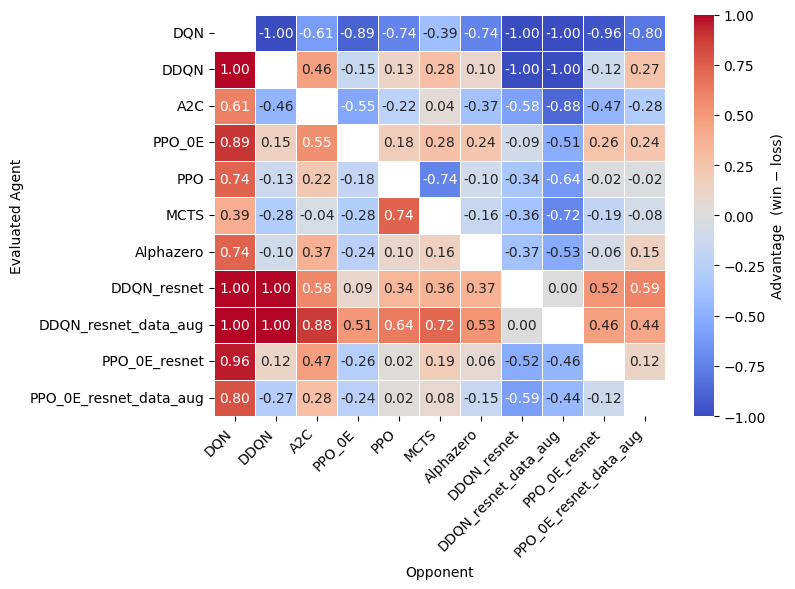

In [27]:
# ---------------------------------------------------------------
# 2.  FIGURE 1 – EXPECTED-SCORE (win – loss) ADVANTAGE HEAT-MAP
# ---------------------------------------------------------------
adv = pd.DataFrame(np.nan, index=agents, columns=agents, dtype=float)

for (row, col), (w, d, l) in raw.items():
    adv.loc[row, col] = w - l
    adv.loc[col, row] = l - w        # anti-symmetric mirror

plt.figure(figsize=(8, 6))
sns.heatmap(
    adv, cmap="coolwarm", center=0, annot=True, fmt=".2f",
    linewidths=0.5, cbar_kws={"label": "Advantage  (win − loss)"},
    mask=adv.isna()
)
# plt.title("Expected-Score Advantage Matrix (Row Agent vs Column Agent)", fontsize=14)
plt.xlabel("Opponent");  plt.ylabel("Evaluated Agent")
plt.xticks(rotation=45, ha="right");  plt.yticks(rotation=0)
plt.tight_layout()
# plt.savefig("figure_advantage_heatmap.png", dpi=300)
plt.show()


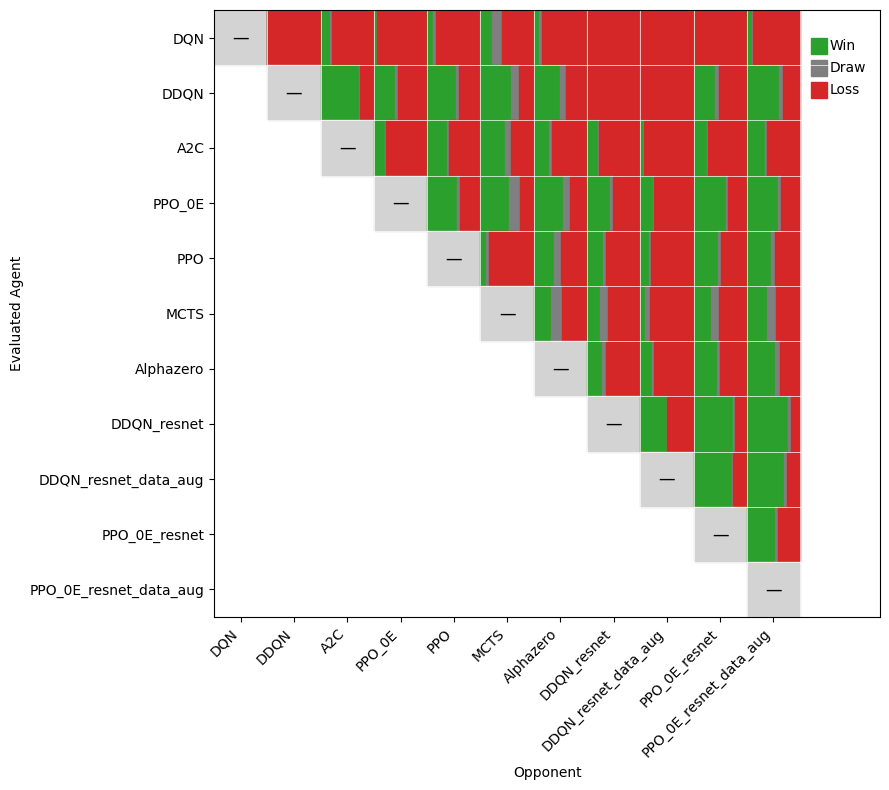

In [ ]:
# ---------------------------------------------------------------
# 3.  FIGURE 2 – RAW WIN/DRAW/LOSS BAR-MATRIX
# ---------------------------------------------------------------
WIN_COLOUR  = "#2ca02c"   # green for Win
DRAW_COLOUR = "#7f7f7f"   # grey  for Draw
LOSS_COLOUR = "#d62728"   # red   for Loss

fig, ax = plt.subplots(figsize=(9, 8))

for i, row_agent in enumerate(agents):
    for j, col_agent in enumerate(agents):
        if i == j:
            # Self-play = grey square with dash
            ax.add_patch(plt.Rectangle((j, i), 1, 1, color="lightgrey"))
            ax.text(j+0.5, i+0.5, "—", ha="center", va="center", fontsize=12)
            continue

        if i > j:
            continue  # only fill below diagonal

        triplet = raw.get((row_agent, col_agent)) or tuple(reversed(raw.get((col_agent, row_agent), (0, 0, 0))))
        if triplet is None:
            # Missing data – leave blank cell
            ax.add_patch(plt.Rectangle((j, i), 1, 1, color="white",
                                       ec="lightgrey", lw=0.5))
            continue

        win, draw, loss = triplet
        # Draw bars left→right, width proportional to probability
        x0 = j
        ax.add_patch(plt.Rectangle((x0,           i), win,              1,
                                   color=WIN_COLOUR))
        ax.add_patch(plt.Rectangle((x0 + win,     i), draw,             1,
                                   color=DRAW_COLOUR))
        ax.add_patch(plt.Rectangle((x0 + win + draw, i), loss,          1,
                                   color=LOSS_COLOUR))

# Cosmetic axis work
ax.set_xticks(np.arange(n)+0.5);  ax.set_yticks(np.arange(n)+0.5)
ax.set_xticklabels(agents, rotation=45, ha="right")
ax.set_yticklabels(agents)
ax.set_xlim(0, n);  ax.set_ylim(0, n);  ax.invert_yaxis()
# ax.set_title("Pairwise Win / Draw / Loss Composition\n(Row Agent vs Column Agent)", fontsize=14)
ax.set_xlabel("Opponent");  ax.set_ylabel("Evaluated Agent")

# Thin white grid
for k in range(n+1):
    ax.axhline(k, color="white", lw=0.5)
    ax.axvline(k, color="white", lw=0.5)

# Legend (add as floating bars)
legend_x, legend_y = n + 0.2, 0.5
for width, label, colour in [(0.3, "Win",  WIN_COLOUR),
                             (0.3, "Draw", DRAW_COLOUR),
                             (0.3, "Loss", LOSS_COLOUR)]:
    ax.add_patch(plt.Rectangle((legend_x, legend_y), width, 0.3,
                               color=colour))
    ax.text(legend_x + width + 0.05, legend_y + 0.15, label,
            va="center", fontsize=10)
    legend_y += 0.4
ax.set_xlim(0, n + 1.5)           # make room for legend on right
plt.tight_layout()
plt.savefig("head_to_head_updated.pdf", format="pdf")

In [29]:
import numpy as np
import pandas as pd
from math import log10

# ────────────────────────────────────────────────────────────────
# Pairwise results (% win, draw, loss) for 1000 games each
# row agent  vs  column agent
pairs = raw
# ────────────────────────────────────────────────────────────────

agents = sorted({a for p in pairs for a in p})
N_GAMES  = 1000
K        = 20          # batch K-factor
ITER     = 50          # a few passes are enough for convergence
ratings  = {a: 1500.0 for a in agents}

def expect(ra, rb):          # logistic expectation
    return 1 / (1 + 10 ** ((rb - ra) / 400))

# Build a list of (row, col, wins, draws, losses) *both directions*
matches = []
for (row, col), (w, d, l) in pairs.items():
    w, d, l = [round(x * N_GAMES) for x in (w, d, l)]
    matches.append((row, col, w, d, l))
    matches.append((col, row, l, d, w))   # reverse view

# Iterative batch Elo
for _ in range(ITER):
    for a, b, wins, draws, losses in matches:
        if wins + draws + losses == 0:
            continue
        score_a   = wins + 0.5 * draws           # 0-N_GAMES
        total     = wins + draws + losses
        exp_a     = expect(ratings[a], ratings[b]) * total
        ratings[a] += K * (score_a - exp_a) / total
        ratings[b] += K * ((total - score_a) - (total - exp_a)) / total

elo_table = pd.Series(ratings).round(1).sort_values(ascending=False)
print(elo_table)


DDQN_resnet_data_aug      1750.4
DDQN_resnet               1692.9
PPO_0E                    1585.1
PPO_0E_resnet             1529.9
Alphazero                 1517.6
DDQN                      1497.9
PPO_0E_resnet_data_aug    1485.0
MCTS                      1473.2
PPO                       1464.6
A2C                       1385.6
DQN                       1117.9
dtype: float64


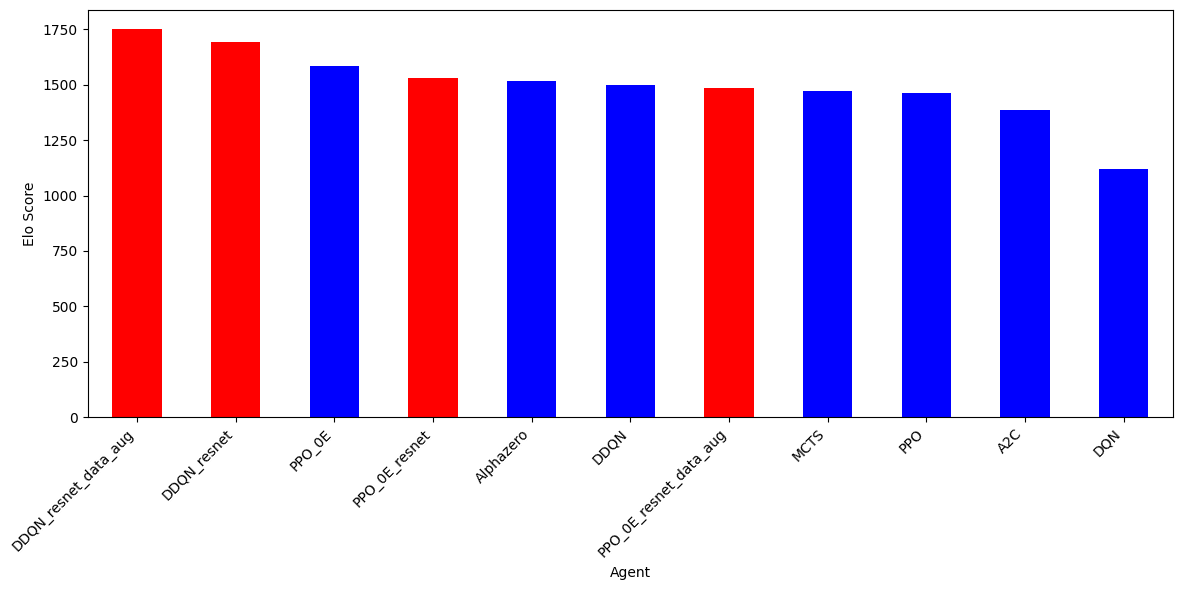

In [31]:
import matplotlib.pyplot as plt

# Define the agents to be colored red
red_agents = {"DDQN_resnet_data_aug", "DDQN_resnet", "PPO_0E_resnet", "PPO_0E_resnet_data_aug"}

# Sort the scores
sorted_scores = elo_table.sort_values(ascending=False)

# Generate bar colors: red for specified agents, default (blue) for others
bar_colors = ['red' if agent in red_agents else 'blue' for agent in sorted_scores.index]

# Plot
plt.figure(figsize=(12, 6))
sorted_scores.plot(kind='bar', color=bar_colors)
plt.xlabel('Agent')
plt.ylabel('Elo Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig("elo_augmented.pdf", format="pdf")